# Pipeline Funnel — Intersection and Image Counts

Traces how many intersections, legs, and photos remain at each stage of the pipeline,
from the raw Rotterdam junction set down to the final sampled images for annotation.

**Stages:**
1. All Rotterdam intersections — inside the ring, street_count ≥ 3, no road-type filter
2. After BST + gemeente filter — only intersections connected to at least one BST-coded gemeente road
3. After merge — dual carriageway and bayonet duplicates collapsed
4. After photo selection — legs that have a matched panorama within 5–55m
5. After stratified sampling — legs selected for annotation and reprojection

**Input files (all pre-computed — no heavy NWB loading needed):**
- `data/processed/intersections.gpkg` — notebook 00 output
- `data/processed/wegvakken_rotterdam_bst.gpkg` — notebook 01 intermediate (BST-filtered roads)
- `data/processed/intersections_merged.gpkg` — notebook 01 output
- `data/processed/leg_photo_selection.csv` — notebook 04 output
- `data/processed/sampled_legs.csv` — notebook 05 output

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project"

INT_RAW_PATH    = os.path.join(PROJECT_DIR, "data", "processed", "intersections.gpkg")
BST_WVK_PATH    = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst.gpkg")
INT_MERGED_PATH = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
LEGS_PATH       = os.path.join(PROJECT_DIR, "data", "processed", "leg_photo_selection.csv")
SAMPLED_PATH    = os.path.join(PROJECT_DIR, "data", "processed", "sampled_legs.csv")

## Stage 1 — All Rotterdam intersections (no road-type filter)

In [2]:
# Load notebook 00 output: all junctions inside the Rotterdam ring with street_count >= 3.
# No BST or gemeente road-type filter has been applied yet at this stage.
int_raw = gpd.read_file(INT_RAW_PATH)

n1_intersections = len(int_raw)
print(f"Stage 1 — intersections (no road-type filter): {n1_intersections:,}")

Stage 1 — intersections (no road-type filter): 5,846


## Stage 2 — After BST + gemeente filter

The BST and gemeente filters are applied to road *segments* (wegvakken), not directly to
intersections. An intersection is considered 'retained' if it is connected to at least one
BST-filtered gemeente road segment — i.e. its JTE_ID appears as a start or end node in
`wegvakken_rotterdam_bst.gpkg`.

In [3]:
# Load the BST-filtered road segments produced by notebook 01.
# We only need the junction ID columns, not the geometry, so read just those.
bst_wvk = gpd.read_file(BST_WVK_PATH, include_fields=["JTE_ID_BEG", "JTE_ID_END"])

# Build the set of all junction IDs that touch at least one BST road segment
bst_jte_ids = set(bst_wvk["JTE_ID_BEG"]) | set(bst_wvk["JTE_ID_END"])

# Count how many of the raw intersections are connected to a BST road
int_bst = int_raw[int_raw["JTE_ID"].isin(bst_jte_ids)]

n2_intersections = len(int_bst)
print(f"Stage 2 — intersections connected to a BST gemeente road: {n2_intersections:,}")
print(f"  Dropped by filter: {n1_intersections - n2_intersections:,}")

C:\Users\Thijs\AppData\Local\Temp\ipykernel_1348\1250974073.py:3: DeprecationWarning: The 'include_fields' and 'ignore_fields' keywords are deprecated, and will be removed in a future release. You can use the 'columns' keyword instead to select which columns to read.
  bst_wvk = gpd.read_file(BST_WVK_PATH, include_fields=["JTE_ID_BEG", "JTE_ID_END"])


Stage 2 — intersections connected to a BST gemeente road: 5,829
  Dropped by filter: 17


## Stage 3 — After merge (true analysis set)

In [4]:
# Load notebook 01 output: dual carriageway pairs and bayonet artefacts have been
# collapsed into single intersection points. This is the set used for all analysis.
int_merged = gpd.read_file(INT_MERGED_PATH)

n3_intersections = len(int_merged)
print(f"Stage 3 — intersections after merge: {n3_intersections:,}")
print(f"  Collapsed by merge: {n2_intersections - n3_intersections:,}")

Stage 3 — intersections after merge: 4,858
  Collapsed by merge: 971


## Stage 4 — After photo selection (notebook 04)

In [5]:
# Load the leg-photo assignment table: one row per intersection leg that has a
# matched panorama within 5–55m. Intersections with no nearby panorama are absent.
legs = pd.read_csv(LEGS_PATH)

n4_intersections = legs["intersection_id"].nunique()
n4_legs          = len(legs)
n4_photos        = legs["photo_filename"].nunique()

print(f"Stage 4 — after photo selection:")
print(f"  Intersections with at least one matched leg : {n4_intersections:,}")
print(f"  Legs (one photo assigned per leg)           : {n4_legs:,}")
print(f"  Unique photos selected                      : {n4_photos:,}")
print(f"  Avg legs per intersection                   : {n4_legs / n4_intersections:.1f}")
print(f"  Intersections without any photo match       : {n3_intersections - n4_intersections:,}")

Stage 4 — after photo selection:
  Intersections with at least one matched leg : 4,726
  Legs (one photo assigned per leg)           : 12,814
  Unique photos selected                      : 12,388
  Avg legs per intersection                   : 2.7
  Intersections without any photo match       : 132


## Stage 5 — After stratified sampling (notebook 05)

In [6]:
# Load the sampled legs: the subset selected by notebook 05 for annotation and reprojection.
# Each row is one leg of a sampled intersection — this is the final image set.
sampled = pd.read_csv(SAMPLED_PATH)

n5_intersections = sampled["intersection_id"].nunique()
n5_legs          = len(sampled)
n5_photos        = sampled["photo_filename"].nunique()

print(f"Stage 5 — after stratified sampling:")
print(f"  Intersections sampled                       : {n5_intersections:,}")
print(f"  Legs (= images to reproject)                : {n5_legs:,}")
print(f"  Unique photos used                          : {n5_photos:,}")
print(f"  Avg legs per intersection                   : {n5_legs / n5_intersections:.1f}")

Stage 5 — after stratified sampling:
  Intersections sampled                       : 266
  Legs (= images to reproject)                : 713
  Unique photos used                          : 713
  Avg legs per intersection                   : 2.7


## Summary funnel

In [7]:
# Build a summary table with the intersection count at each stage and
# the percentage retained relative to the previous step.
rows = [
    ("1. Rotterdam intersections (no filter)",  n1_intersections, None),
    ("2. After BST + gemeente filter",          n2_intersections, n1_intersections),
    ("3. After merge",                          n3_intersections, n2_intersections),
    ("4. With photo match (intersections)",     n4_intersections, n3_intersections),
]

print(f"{'Stage':<45} {'N':>7}  {'Retained':>9}")
print("-" * 65)
for label, n, prev in rows:
    pct = f"{n / prev * 100:.1f}%" if prev else "—"
    print(f"{label:<45} {n:>7,}  {pct:>9}")

print()
print(f"{'Stage':<45} {'Legs':>7}  {'Photos':>7}  {'Retained':>9}")
print("-" * 75)

# Leg/photo rows — retained % relative to stage 4
leg_rows = [
    ("4. All legs with photo match",   n4_legs, n4_photos, None),
    ("5. After stratified sampling",   n5_legs, n5_photos, n4_legs),
]
for label, nl, np_, prev in leg_rows:
    pct = f"{nl / prev * 100:.1f}%" if prev else "—"
    print(f"{label:<45} {nl:>7,}  {np_:>7,}  {pct:>9}")

Stage                                               N   Retained
-----------------------------------------------------------------
1. Rotterdam intersections (no filter)          5,846          —
2. After BST + gemeente filter                  5,829      99.7%
3. After merge                                  4,858      83.3%
4. With photo match (intersections)             4,726      97.3%

Stage                                            Legs   Photos   Retained
---------------------------------------------------------------------------
4. All legs with photo match                   12,814   12,388          —
5. After stratified sampling                      713      713       5.6%


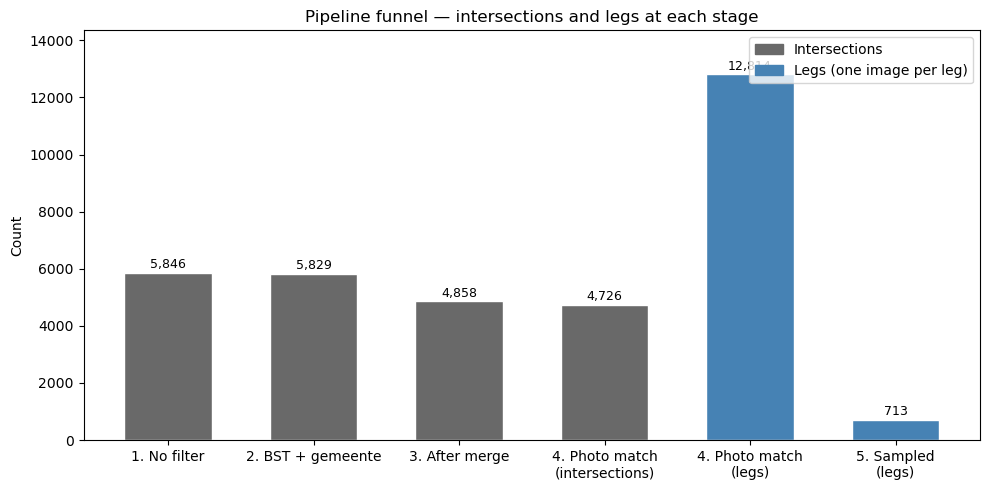

In [8]:
# Bar chart visualising the intersection funnel across all five stages.
# Stage 4 and 5 show the leg count (right axis) alongside intersections.
labels = [
    "1. No filter",
    "2. BST + gemeente",
    "3. After merge",
    "4. Photo match\n(intersections)",
    "4. Photo match\n(legs)",
    "5. Sampled\n(legs)",
]
values = [n1_intersections, n2_intersections, n3_intersections,
          n4_intersections, n4_legs, n5_legs]

# Colour the bars: grey for intersection counts, steelblue for leg counts
colors = ["dimgrey", "dimgrey", "dimgrey", "dimgrey", "steelblue", "steelblue"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, values, color=colors, edgecolor="white", width=0.6)

# Label each bar with its count
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{val:,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_ylabel("Count")
ax.set_title("Pipeline funnel — intersections and legs at each stage")
ax.set_ylim(0, max(values) * 1.12)

# Legend explaining the colour coding
from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(color="dimgrey",   label="Intersections"),
        Patch(color="steelblue", label="Legs (one image per leg)"),
    ],
    loc="upper right"
)

plt.tight_layout()
plt.show()